# Libraries

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

# Exploratory Data Analysis

In [ ]:
def plot_time_series(df, title):
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["inflasi"], marker="o")
    plt.title(title)
    plt.xlabel("Tahun")
    plt.ylabel("Inflasi (%)")
    plt.grid(True)
    plt.show()


def plot_rolling(df, title):
    rolling_mean = df["inflasi"].rolling(window=12).mean()
    rolling_std = df["inflasi"].rolling(window=12).std()

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["inflasi"], label="Data Aktual")
    plt.plot(rolling_mean.index, rolling_mean, label="Rolling Mean 12 Bulan")
    plt.plot(rolling_std.index, rolling_std, label="Rolling Std 12 Bulan")

    plt.title(title)
    plt.xlabel("Tahun")
    plt.ylabel("Inflasi (%)")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_decomposition(df, title):
    decomposition = seasonal_decompose(
        df["inflasi"].dropna(),
        model="additive",
        period=12
    )

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle(title, y=1.02)
    plt.show()

# Stationarity Test

In [3]:
def adf_test(series, nama="Data"):
    result = adfuller(series.dropna())

    print(f"ADF Test - {nama}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] < 0.05:
        print("Kesimpulan: stasioner")
    else:
        print("Kesimpulan: belum stasioner")

    print("-" * 60)

# ACF and PACF Plot

In [4]:
def plot_acf_pacf(series, title, lags=36):
    plt.figure(figsize=(10, 4))
    plot_acf(series.dropna(), lags=lags)
    plt.title(f"ACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_pacf(series.dropna(), lags=lags, method="ywm")
    plt.title(f"PACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Partial Autocorrelation")
    plt.show()


def stationarity_analysis(train, nama_data):
    train_asli = train.dropna()
    train_d1 = train.diff().dropna()
    train_D1 = train.diff(12).dropna()
    train_d1_D1 = train.diff().diff(12).dropna()

    adf_test(train_asli, f"{nama_data} - Data Train")
    adf_test(train_d1, f"{nama_data} - Differencing Regular d=1")
    adf_test(train_D1, f"{nama_data} - Differencing Musiman D=1")
    adf_test(train_d1_D1, f"{nama_data} - Differencing Regular d=1 dan Musiman D=1")


def acf_pacf_analysis(train, nama_data, lags=36):
    train_asli = train.dropna()
    train_d1 = train.diff().dropna()
    train_D1 = train.diff(12).dropna()
    train_d1_D1 = train.diff().diff(12).dropna()

    plot_acf_pacf(train_asli, f"{nama_data} - Data Train Asli", lags=lags)
    plot_acf_pacf(train_d1, f"{nama_data} - Differencing Regular d=1", lags=lags)
    plot_acf_pacf(train_D1, f"{nama_data} - Differencing Musiman D=1", lags=lags)
    plot_acf_pacf(train_d1_D1, f"{nama_data} - Differencing Regular d=1 dan Musiman D=1", lags=lags)

# SARIMA Model Estimation (Grid Search)

In [5]:
def grid_search_sarima(train, test, s=12):
    results = []

    p_values = range(0, 3)
    q_values = range(0, 3)
    P_values = range(0, 2)
    Q_values = range(0, 2)

    diff_candidates = [
        (1, 0),
        (0, 1),
        (1, 1)
    ]

    for d, D in diff_candidates:
        for p in p_values:
            for q in q_values:
                for P in P_values:
                    for Q in Q_values:
                        order = (p, d, q)
                        seasonal_order = (P, D, Q, s)

                        try:
                            model = SARIMAX(
                                train,
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            fitted = model.fit(disp=False, maxiter=300)

                            forecast = fitted.get_forecast(steps=len(test))
                            pred = forecast.predicted_mean
                            pred.index = test.index

                            rmse = np.sqrt(mean_squared_error(test, pred))
                            mae = mean_absolute_error(test, pred)

                            lb = acorr_ljungbox(
                                fitted.resid.dropna(),
                                lags=[12],
                                return_df=True
                            )

                            ljungbox_pvalue = lb["lb_pvalue"].iloc[0]

                            try:
                                shapiro_pvalue = shapiro(fitted.resid.dropna()).pvalue
                            except:
                                shapiro_pvalue = np.nan

                            results.append({
                                "order": order,
                                "seasonal_order": seasonal_order,
                                "aic": fitted.aic,
                                "bic": fitted.bic,
                                "rmse": rmse,
                                "mae": mae,
                                "ljungbox_pvalue": ljungbox_pvalue,
                                "shapiro_pvalue": shapiro_pvalue
                            })

                        except:
                            continue

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["aic", "rmse"]).reset_index(drop=True)

    return df_results

# Selection, Fit, and Model Evaluation

In [6]:
def select_best_model(df_results):
    valid_models = df_results[
        (df_results["ljungbox_pvalue"] > 0.05) &
        (df_results["shapiro_pvalue"] > 0.05)
    ].copy()

    print("Jumlah model yang lolos diagnostic checking:", len(valid_models))

    if len(valid_models) > 0:
        best_model = valid_models.sort_values(["rmse", "aic"]).iloc[0]
    else:
        best_model = df_results.iloc[0]

    return best_model, valid_models


def fit_sarima(train, order, seasonal_order):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False, maxiter=300)

    return fitted


def evaluate_model(fitted, test):
    forecast = fitted.get_forecast(steps=len(test))
    pred = forecast.predicted_mean
    pred.index = test.index

    eval_df = pd.DataFrame({
        "actual": test,
        "forecast": pred
    })

    eval_df["error"] = eval_df["actual"] - eval_df["forecast"]
    eval_df["abs_error"] = eval_df["error"].abs()
    eval_df["squared_error"] = eval_df["error"] ** 2

    rmse = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["forecast"]))
    mae = mean_absolute_error(eval_df["actual"], eval_df["forecast"])

    print("RMSE:", rmse)
    print("MAE :", mae)

    return eval_df, rmse, mae

# Diagnostic Checking dan Forecast

In [ ]:
def diagnostic_check(fitted, title):
    residual = fitted.resid.dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(residual)
    plt.title(f"Residual Model SARIMA - {title}")
    plt.xlabel("Tahun")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_acf(residual, lags=36)
    plt.title(f"ACF Residual - {title}")
    plt.show()

    lb = acorr_ljungbox(residual, lags=[12, 24], return_df=True)
    print("Ljung-Box Test:")
    display(lb)

    shapiro_stat, shapiro_p = shapiro(residual)
    print("Shapiro-Wilk Test")
    print("Statistic:", shapiro_stat)
    print("p-value  :", shapiro_p)


def forecast_future(y, order, seasonal_order, steps=12):
    final_model = SARIMAX(
        y,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    final_fitted = final_model.fit(disp=False, maxiter=300)

    forecast = final_fitted.get_forecast(steps=steps)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int(alpha=0.05)

    df_forecast = pd.DataFrame({
        "forecast": forecast_mean,
        "lower_95": forecast_ci.iloc[:, 0],
        "upper_95": forecast_ci.iloc[:, 1]
    })

    return df_forecast, final_fitted


def plot_forecast(y, df_forecast, title):
    plt.figure(figsize=(12, 5))

    plt.plot(y.index, y, label="Data Historis")
    plt.plot(
        df_forecast.index,
        df_forecast["forecast"],
        marker="o",
        linestyle="--",
        label="Forecast"
    )

    plt.fill_between(
        df_forecast.index,
        df_forecast["lower_95"],
        df_forecast["upper_95"],
        alpha=0.2,
        label="Interval Prediksi 95%"
    )

    plt.title(title)
    plt.xlabel("Tahun")
    plt.ylabel("Inflasi (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Pipeline

In [8]:
def run_sarima_pipeline(df, nama_data):
    print("=" * 70)
    print(f"ANALISIS SARIMA: {nama_data}")
    print("=" * 70)

    y = df["inflasi"].dropna()

    train = y.loc["2015-01-01":"2024-12-01"]
    test = y.loc["2025-01-01":"2025-12-01"]

    print("Jumlah train:", len(train))
    print("Jumlah test:", len(test))
    print("Periode train:", train.index.min(), "-", train.index.max())
    print("Periode test:", test.index.min(), "-", test.index.max())

    plot_time_series(df, f"Inflasi Bulanan {nama_data}, 2015–2025")
    plot_rolling(df, f"Rolling Mean dan Rolling Std Inflasi {nama_data}")
    plot_decomposition(df, f"Dekomposisi Inflasi Bulanan {nama_data}")

    stationarity_analysis(train, nama_data)
    acf_pacf_analysis(train, nama_data, lags=36)

    df_results = grid_search_sarima(train, test, s=12)

    print("10 model terbaik berdasarkan AIC:")
    display(df_results.head(10))

    best_model, valid_models = select_best_model(df_results)

    print("Model SARIMA terbaik:")
    display(best_model)

    best_order = best_model["order"]
    best_seasonal_order = best_model["seasonal_order"]

    fitted = fit_sarima(train, best_order, best_seasonal_order)

    print(fitted.summary())

    eval_df, rmse, mae = evaluate_model(fitted, test)

    print("Evaluasi out-sample:")
    display(eval_df)

    diagnostic_check(fitted, nama_data)

    df_forecast, final_fitted = forecast_future(
        y,
        best_order,
        best_seasonal_order,
        steps=12
    )

    print("Forecast 12 bulan ke depan:")
    display(df_forecast)

    plot_forecast(
        y,
        df_forecast,
        f"Forecast Inflasi Bulanan {nama_data} Tahun 2026"
    )

    summary = {
        "nama_data": nama_data,
        "order": best_order,
        "seasonal_order": best_seasonal_order,
        "aic": best_model["aic"],
        "bic": best_model["bic"],
        "rmse": rmse,
        "mae": mae
    }

    return {
        "summary": summary,
        "results": df_results,
        "best_model": best_model,
        "fitted": fitted,
        "eval_df": eval_df,
        "forecast": df_forecast
    }

# Indonesia

In [10]:
df_indonesia = pd.read_csv("dataset/inflasi_indonesia_2015_2025_clean.csv")
df_indonesia["tanggal"] = pd.to_datetime(df_indonesia["tanggal"])
df_indonesia["inflasi"] = pd.to_numeric(df_indonesia["inflasi"], errors="coerce")

df_indonesia = (
    df_indonesia
    .set_index("tanggal")
    .sort_index()
    .asfreq("MS")
)

df_indonesia = df_indonesia.loc["2015-01-01":"2025-12-01"]
df_indonesia.head()

,wilayah,inflasi
tanggal,,
2015-01-01,INDONESIA,-0.24
2015-02-01,INDONESIA,-0.36
2015-03-01,INDONESIA,0.17
2015-04-01,INDONESIA,0.36
2015-05-01,INDONESIA,0.50


ANALISIS SARIMA: Indonesia
Jumlah train: 120
Jumlah test: 12
Periode train: 2015-01-01 00:00:00 - 2024-12-01 00:00:00
Periode test: 2025-01-01 00:00:00 - 2025-12-01 00:00:00


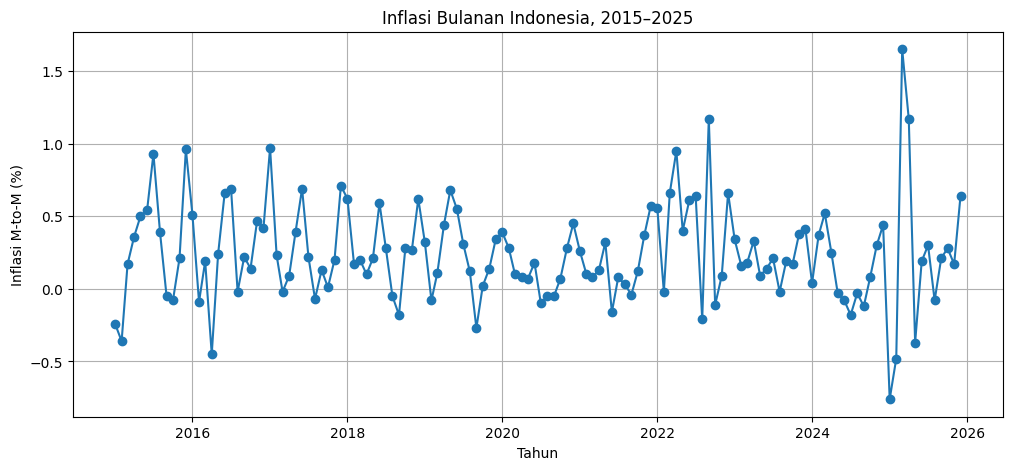

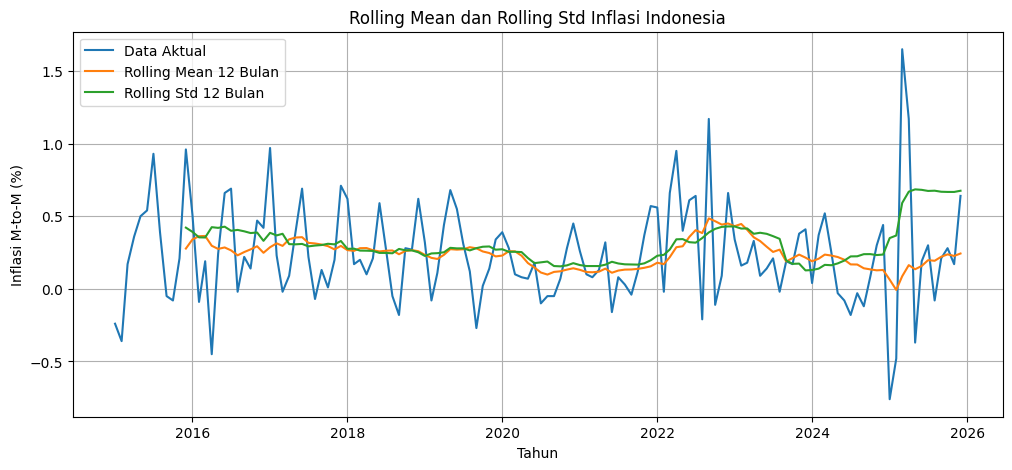

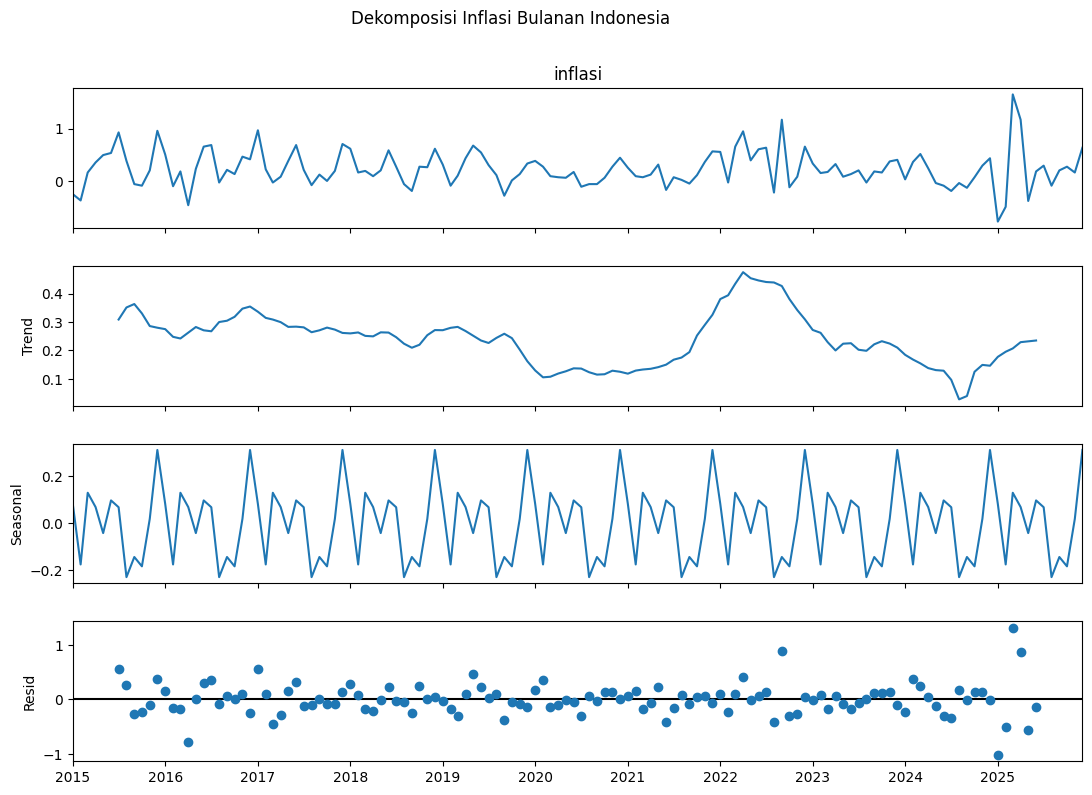

ADF Test - Indonesia - Data Train
ADF Statistic: -2.342914127624872
p-value: 0.15850047553666863
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: belum stasioner
------------------------------------------------------------
ADF Test - Indonesia - Differencing Regular d=1
ADF Statistic: -6.3586589435028245
p-value: 2.5059709355504543e-08
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Indonesia - Differencing Musiman D=1
ADF Statistic: -4.4172180787280295
p-value: 0.00027668420297991973
Critical Values:
1%: -3.4942202045135513
5%: -2.889485291005291
10%: -2.5816762131519275
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Indonesia - Differencing Regular d=1 dan Musiman D=1
ADF Statistic: -4.280207200881504
p-value: 0.0004806069476066247
Critical Values:
1%:

<Figure size 1000x400 with 0 Axes>

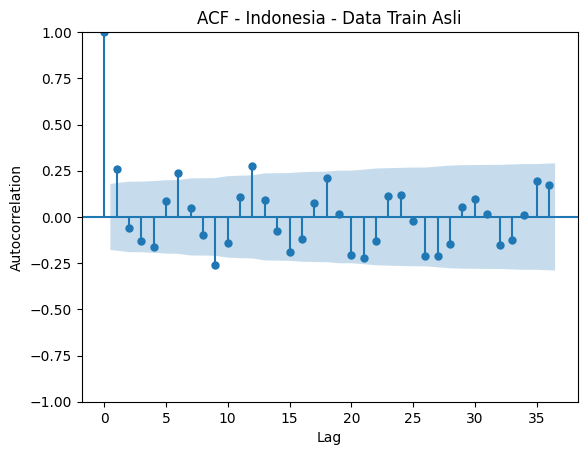

<Figure size 1000x400 with 0 Axes>

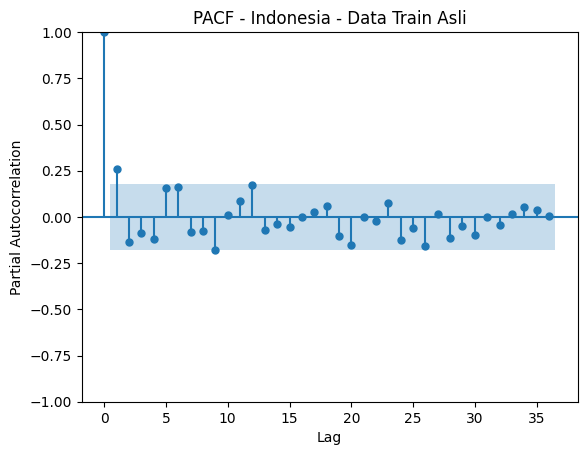

<Figure size 1000x400 with 0 Axes>

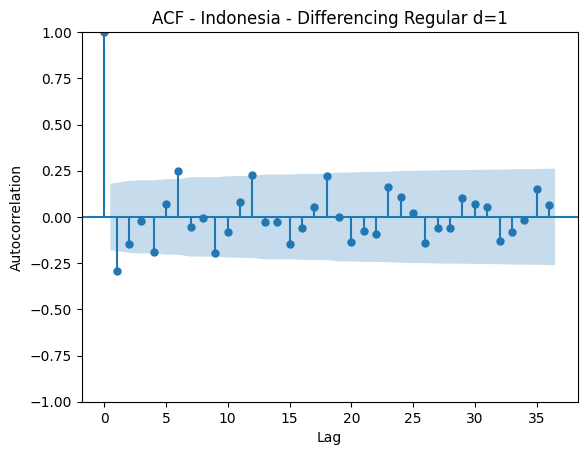

<Figure size 1000x400 with 0 Axes>

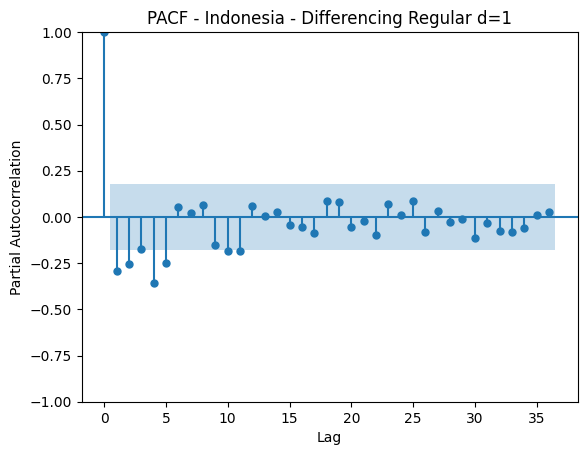

<Figure size 1000x400 with 0 Axes>

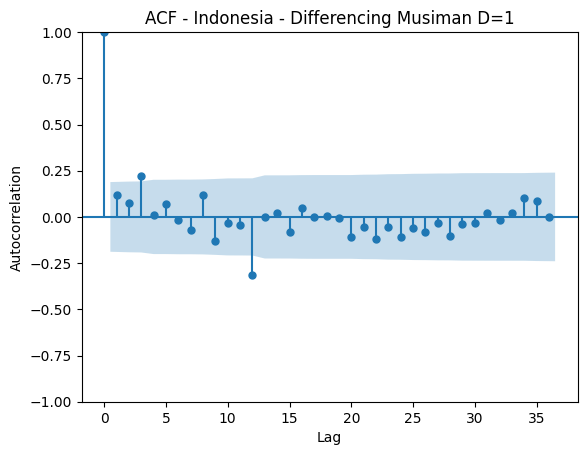

<Figure size 1000x400 with 0 Axes>

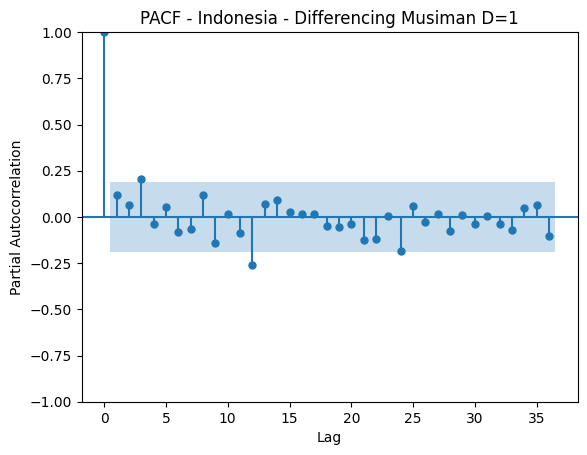

<Figure size 1000x400 with 0 Axes>

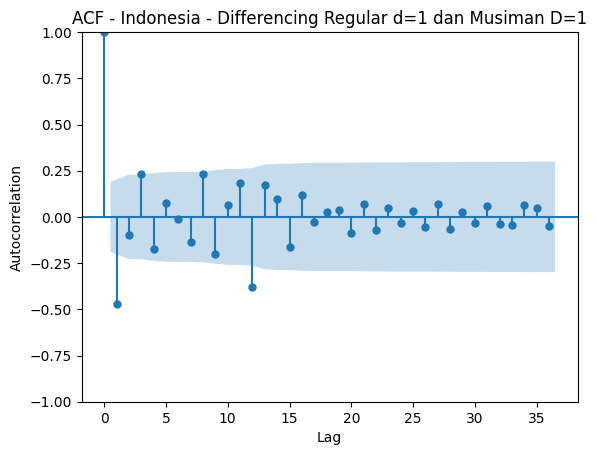

<Figure size 1000x400 with 0 Axes>

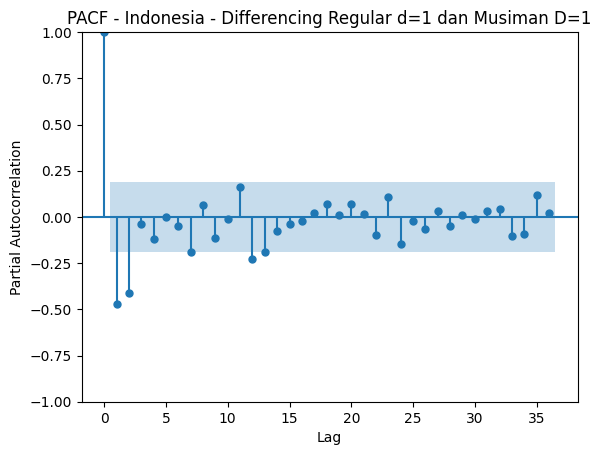

C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10 model terbaik berdasarkan AIC:


,order,seasonal_order,aic,bic,rmse,mae,ljungbox_pvalue,shapiro_pvalue
0,"(0, 1, 2)","(1, 0, 1, 12)",20.373349,33.595304,0.639352,0.465797,0.798092,0.362375
1,"(1, 1, 2)","(1, 0, 1, 12)",20.729758,36.596103,0.638203,0.464860,0.594194,0.079523
2,"(2, 1, 2)","(1, 0, 1, 12)",21.850661,40.361398,0.630007,0.461677,0.350863,0.237542
3,"(0, 1, 1)","(1, 0, 1, 12)",22.881202,33.497043,0.638522,0.465540,0.739208,0.418195
4,"(1, 1, 1)","(1, 0, 1, 12)",24.174088,37.443890,0.638024,0.457809,0.843301,0.020084
5,"(0, 0, 1)","(0, 1, 1, 12)",26.641994,34.271879,0.605628,0.427644,0.219499,0.000137
6,"(1, 0, 1)","(0, 1, 1, 12)",26.743591,36.916770,0.595486,0.426697,0.608319,0.011011
7,"(2, 1, 1)","(1, 0, 1, 12)",26.860192,42.783955,0.637376,0.458037,0.771107,0.047771
8,"(1, 0, 0)","(0, 1, 1, 12)",27.018545,34.680175,0.603629,0.426581,0.546146,0.000388
9,"(1, 1, 2)","(1, 0, 0, 12)",27.086071,40.403267,0.620320,0.464910,0.076191,0.002818


Jumlah model yang lolos diagnostic checking: 29
Model SARIMA terbaik:


order                  (2, 0, 2)
seasonal_order     (1, 1, 0, 12)
aic                    41.009165
bic                    56.268934
rmse                    0.590769
mae                     0.458016
ljungbox_pvalue         0.773102
shapiro_pvalue          0.081517
Name: 52, dtype: object

                                      SARIMAX Results                                      
Dep. Variable:                             inflasi   No. Observations:                  120
Model:             SARIMAX(2, 0, 2)x(1, 1, [], 12)   Log Likelihood                 -14.505
Date:                             Mon, 22 Jun 2026   AIC                             41.009
Time:                                     19:07:44   BIC                             56.269
Sample:                                 01-01-2015   HQIC                            47.173
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0383      0.443      2.344      0.019       0.170       1.906
ar.L2         -0.2852      

,actual,forecast,error,abs_error,squared_error
tanggal,,,,,
2025-01-01,-0.76,0.139526,-0.899526,0.899526,0.809147
2025-02-01,-0.48,0.288459,-0.768459,0.768459,0.590529
2025-03-01,1.65,0.392342,1.257658,1.257658,1.581704
2025-04-01,1.17,0.290481,0.879519,0.879519,0.773554
2025-05-01,-0.37,0.024343,-0.394343,0.394343,0.155506
2025-06-01,0.19,0.012332,0.177668,0.177668,0.031566
2025-07-01,0.30,-0.021038,0.321038,0.321038,0.103065
2025-08-01,-0.08,-0.024623,-0.055377,0.055377,0.003067
2025-09-01,0.21,0.005158,0.204842,0.204842,0.041960


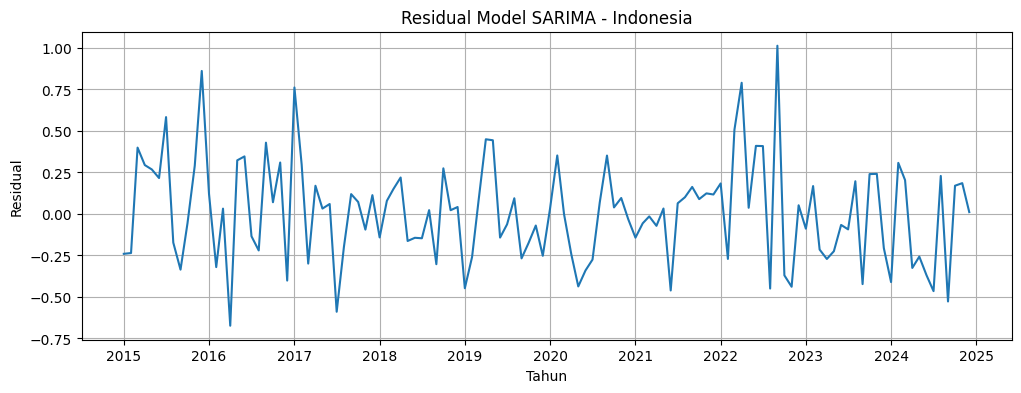

<Figure size 1000x400 with 0 Axes>

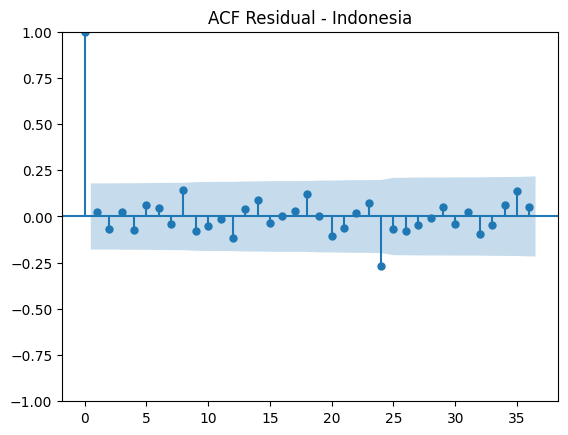

Ljung-Box Test:


,lb_stat,lb_pvalue
12,8.152505,0.773102
24,26.152413,0.345477


Shapiro-Wilk Test
Statistic: 0.9806311311078403
p-value  : 0.08151736711633988
Forecast 12 bulan ke depan:


,forecast,lower_95,upper_95
2026-01-01,-0.422975,-1.080806,0.234856
2026-02-01,-0.200482,-0.871235,0.470271
2026-03-01,1.270994,0.599524,1.942463
2026-04-01,0.844405,0.171999,1.516812
2026-05-01,-0.247101,-0.919551,0.425349
2026-06-01,0.094626,-0.577893,0.767145
2026-07-01,0.133539,-0.538982,0.806061
2026-08-01,-0.062819,-0.735345,0.609708
2026-09-01,0.095087,-0.577440,0.767613
2026-10-01,0.210101,-0.462426,0.882629


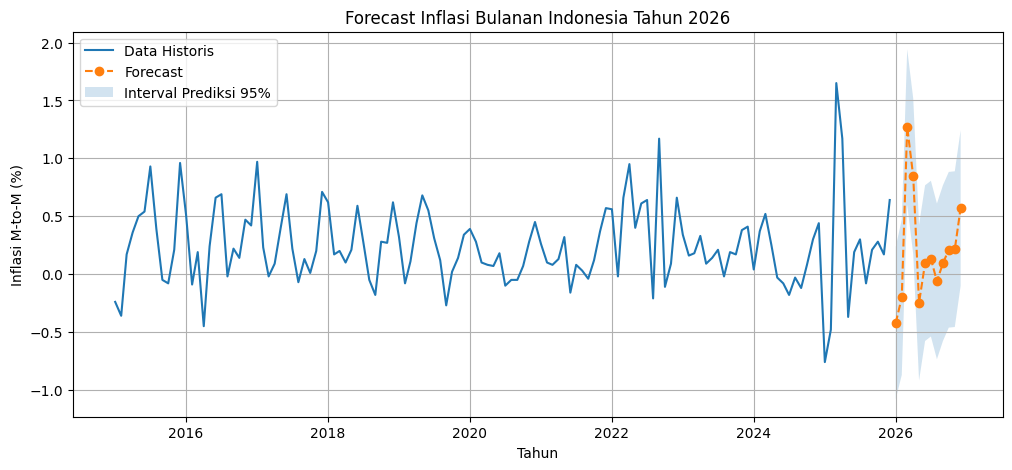

In [11]:
hasil_indonesia = run_sarima_pipeline(df_indonesia, "Indonesia")

In [12]:
hasil_indonesia["results"].to_csv("top_model_sarima_indonesia.csv", index=False)
hasil_indonesia["eval_df"].to_csv("evaluasi_outsample_2025_indonesia.csv")
hasil_indonesia["forecast"].to_csv("forecast_inflasi_2026_indonesia.csv")

# JATIM

In [13]:
df_jatim = pd.read_csv("dataset/Data_Jatim.csv")

df_jatim["Tanggal"] = pd.to_datetime(df_jatim["Tanggal"])
df_jatim["Inflasi"] = pd.to_numeric(df_jatim["Inflasi"], errors="coerce")
df_jatim.head()

,Tanggal,KOTA,Inflasi
0,2015-01-01,BANYUWANGI,0.08
1,2015-02-01,BANYUWANGI,-1.02
2,2015-03-01,BANYUWANGI,0.09
3,2015-04-01,BANYUWANGI,0.36
4,2015-05-01,BANYUWANGI,0.55


## Surabaya

In [15]:
df_surabaya = df_jatim[
    df_jatim["KOTA"].str.upper() == "KOTA SURABAYA"
].copy()

df_surabaya = (
    df_surabaya.rename(columns={
        "Tanggal": "tanggal",
        "Inflasi": "inflasi"
    }).set_index("tanggal").sort_index().asfreq("MS")
)

df_surabaya = df_surabaya.loc["2015-01-01":"2025-12-01"]
df_surabaya.head()

,KOTA,inflasi
tanggal,,
2015-01-01,KOTA SURABAYA,0.41
2015-02-01,KOTA SURABAYA,-0.42
2015-03-01,KOTA SURABAYA,0.36
2015-04-01,KOTA SURABAYA,0.41
2015-05-01,KOTA SURABAYA,0.39


ANALISIS SARIMA: Kota Surabaya
Jumlah train: 120
Jumlah test: 12
Periode train: 2015-01-01 00:00:00 - 2024-12-01 00:00:00
Periode test: 2025-01-01 00:00:00 - 2025-12-01 00:00:00


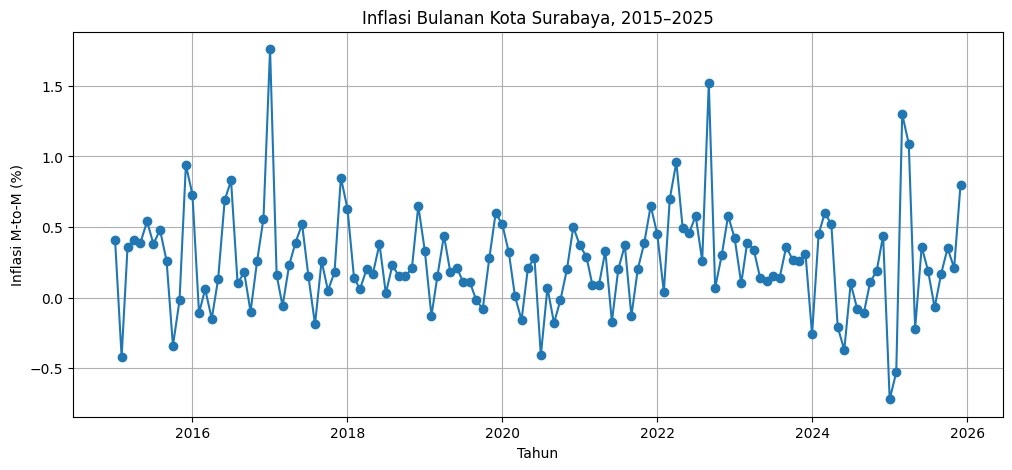

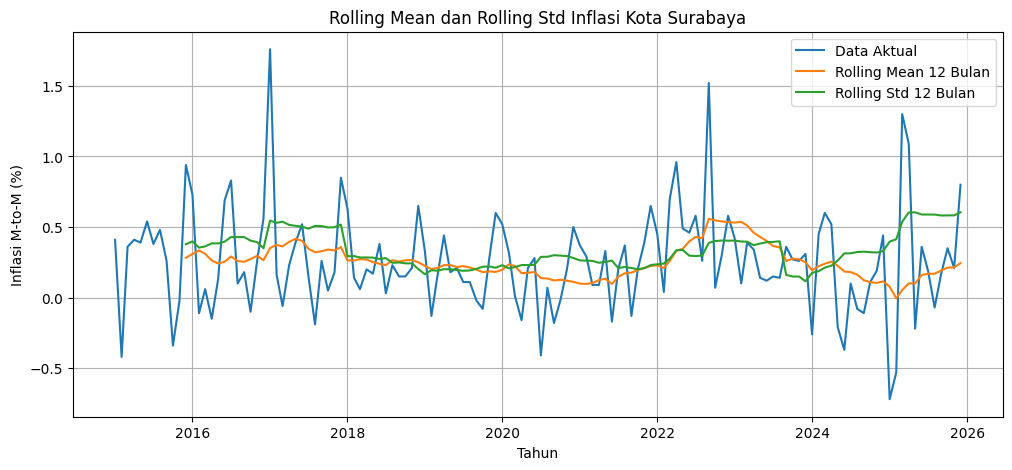

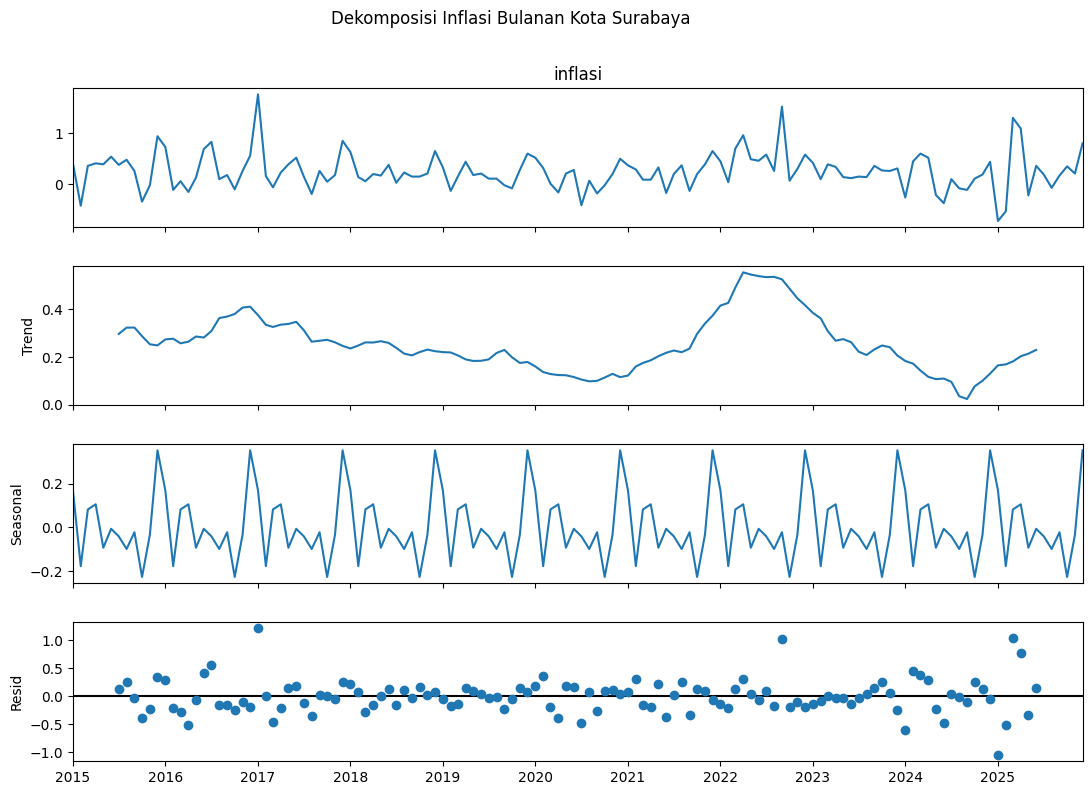

ADF Test - Kota Surabaya - Data Train
ADF Statistic: -8.820828804885524
p-value: 1.87936011389528e-14
Critical Values:
1%: -3.4865346059036564
5%: -2.8861509858476264
10%: -2.579896092790057
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Kota Surabaya - Differencing Regular d=1
ADF Statistic: -5.911799334459224
p-value: 2.628222193191462e-07
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Kota Surabaya - Differencing Musiman D=1
ADF Statistic: -3.1931593853960485
p-value: 0.02038407107205828
Critical Values:
1%: -3.5003788874873405
5%: -2.8921519665075235
10%: -2.5830997960069446
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Kota Surabaya - Differencing Regular d=1 dan Musiman D=1
ADF Statistic: -4.017351954604251
p-value: 0.0013223277041288317
Critical Value

<Figure size 1000x400 with 0 Axes>

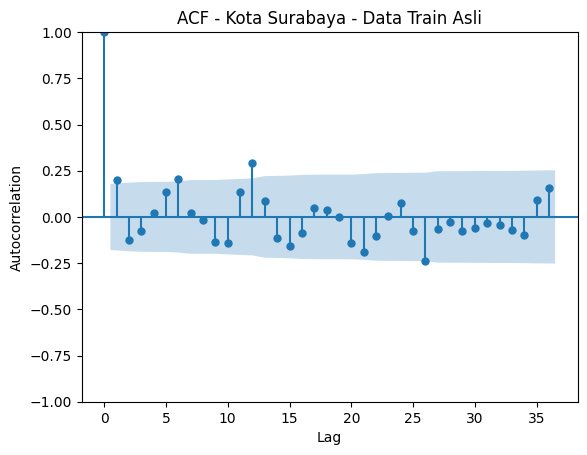

<Figure size 1000x400 with 0 Axes>

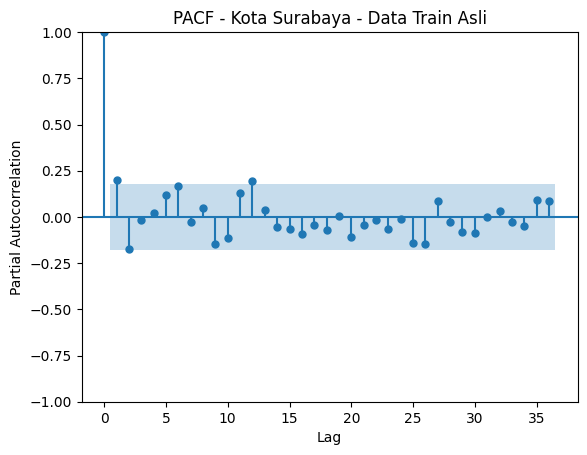

<Figure size 1000x400 with 0 Axes>

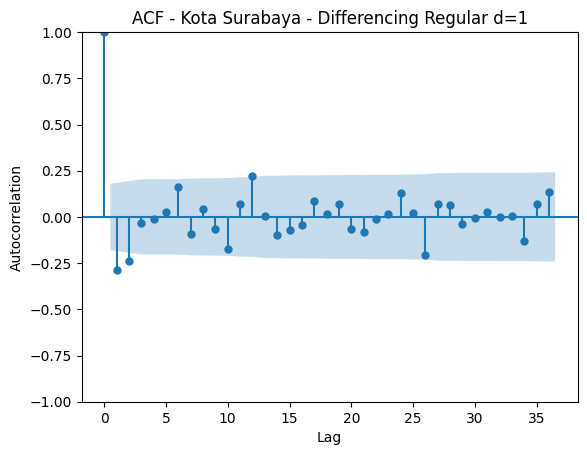

<Figure size 1000x400 with 0 Axes>

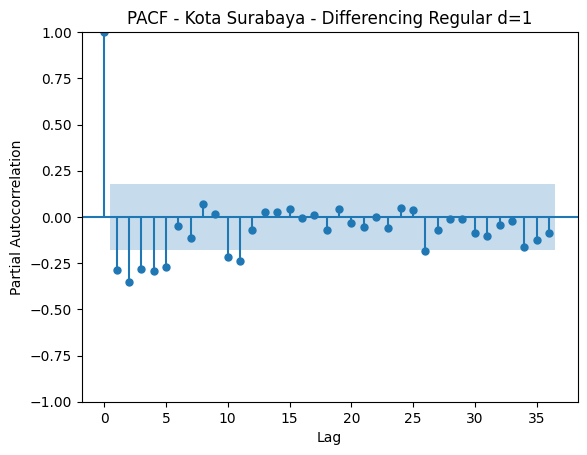

<Figure size 1000x400 with 0 Axes>

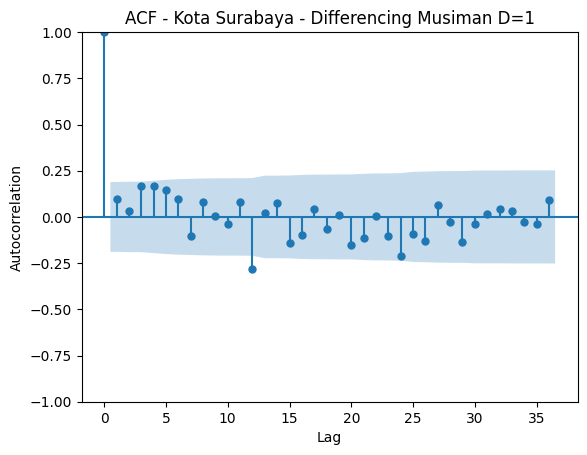

<Figure size 1000x400 with 0 Axes>

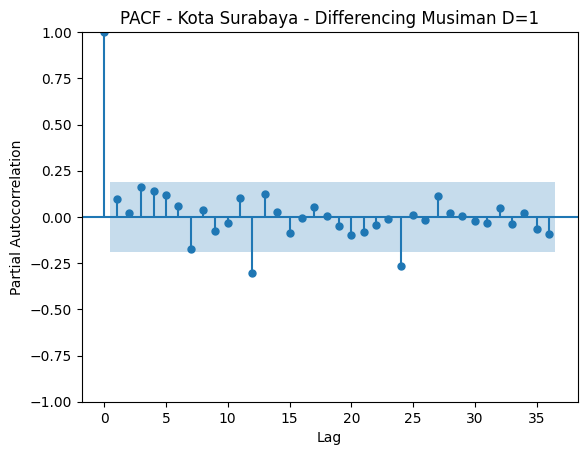

<Figure size 1000x400 with 0 Axes>

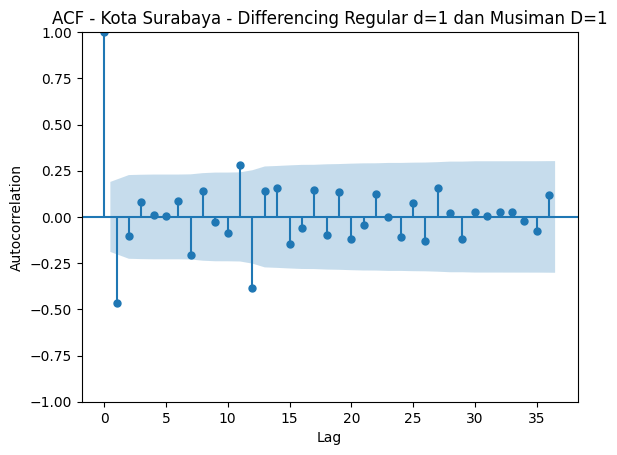

<Figure size 1000x400 with 0 Axes>

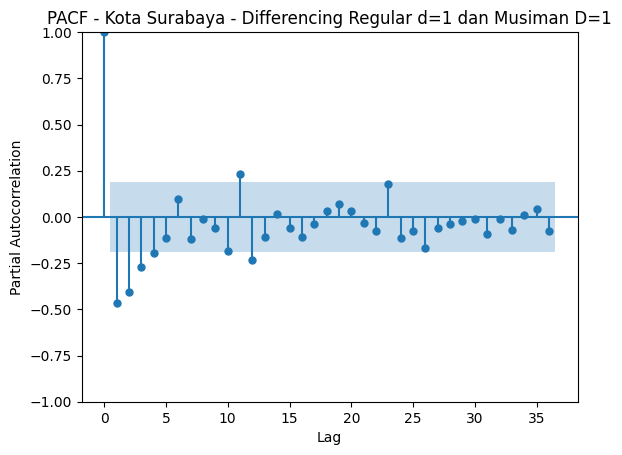

C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10 model terbaik berdasarkan AIC:


,order,seasonal_order,aic,bic,rmse,mae,ljungbox_pvalue,shapiro_pvalue
0,"(0, 1, 1)","(1, 0, 1, 12)",47.629114,58.244955,0.585442,0.452051,0.655488,0.000274
1,"(1, 1, 1)","(1, 0, 1, 12)",49.128406,62.398207,0.590752,0.452177,0.609471,0.000149
2,"(0, 1, 2)","(1, 0, 1, 12)",49.388570,62.610524,0.592540,0.453799,0.584846,0.000126
3,"(1, 1, 2)","(1, 0, 1, 12)",49.814889,65.681234,0.591021,0.453798,0.560585,0.000039
4,"(2, 1, 1)","(1, 0, 1, 12)",49.946292,65.870054,0.581218,0.451140,0.648991,0.000320
5,"(2, 1, 2)","(1, 0, 1, 12)",51.143210,69.653946,0.583915,0.452018,0.690413,0.000151
6,"(0, 0, 1)","(0, 1, 1, 12)",55.846909,63.476793,0.510200,0.398535,0.234814,0.000135
7,"(1, 0, 0)","(0, 1, 1, 12)",56.626354,64.287984,0.502522,0.393931,0.433315,0.000133
8,"(1, 0, 2)","(0, 1, 1, 12)",56.783300,69.446298,0.499971,0.390349,0.254732,0.000185
9,"(1, 0, 1)","(0, 1, 1, 12)",56.850312,67.023491,0.491820,0.385023,0.485215,0.000170


Jumlah model yang lolos diagnostic checking: 0
Model SARIMA terbaik:


order                  (0, 1, 1)
seasonal_order     (1, 0, 1, 12)
aic                    47.629114
bic                    58.244955
rmse                    0.585442
mae                     0.452051
ljungbox_pvalue         0.655488
shapiro_pvalue          0.000274
Name: 0, dtype: object

                                     SARIMAX Results                                      
Dep. Variable:                            inflasi   No. Observations:                  120
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 -19.815
Date:                            Mon, 22 Jun 2026   AIC                             47.629
Time:                                    19:11:36   BIC                             58.245
Sample:                                01-01-2015   HQIC                            51.931
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8444      0.062    -13.634      0.000      -0.966      -0.723
ar.S.L12       0.6936      0.071   

,actual,forecast,error,abs_error,squared_error
tanggal,,,,,
2025-01-01,-0.72,0.172221,-0.892221,0.892221,0.796058
2025-02-01,-0.53,0.130444,-0.660444,0.660444,0.436186
2025-03-01,1.30,0.148547,1.151453,1.151453,1.325844
2025-04-01,1.09,0.150565,0.939435,0.939435,0.882537
2025-05-01,-0.22,0.137416,-0.357416,0.357416,0.127746
2025-06-01,0.36,0.139777,0.220223,0.220223,0.048498
2025-07-01,0.19,0.142564,0.047436,0.047436,0.002250
2025-08-01,-0.07,0.134503,-0.204503,0.204503,0.041821
2025-09-01,0.17,0.142338,0.027662,0.027662,0.000765


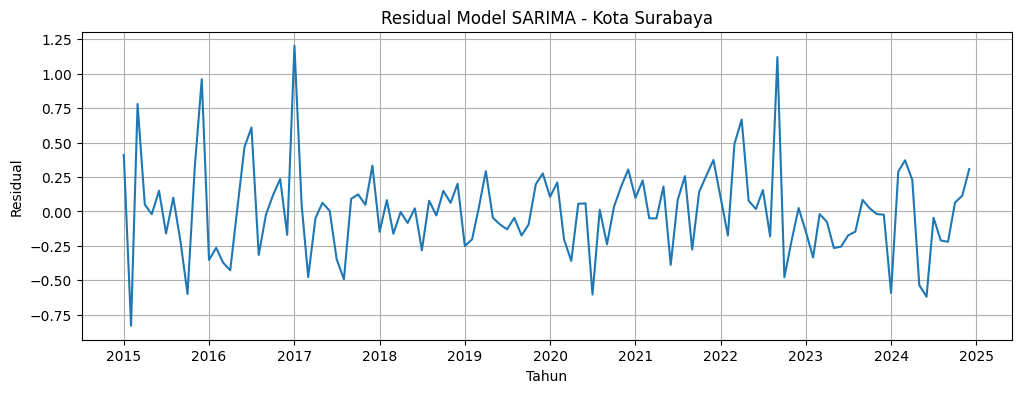

<Figure size 1000x400 with 0 Axes>

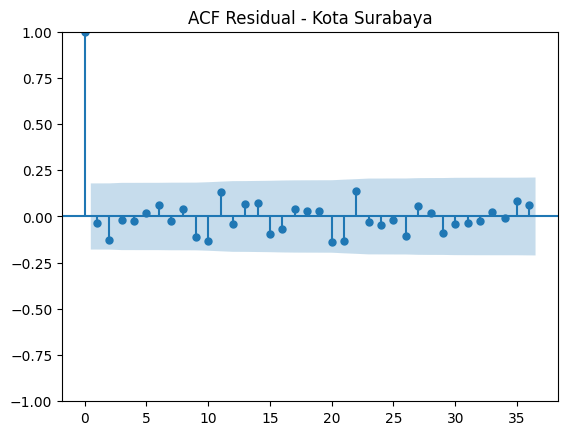

Ljung-Box Test:


,lb_stat,lb_pvalue
12,9.548678,0.655488
24,22.241492,0.564855


Shapiro-Wilk Test
Statistic: 0.951395630720096
p-value  : 0.0002739069789262649
Forecast 12 bulan ke depan:


,forecast,lower_95,upper_95
2026-01-01,0.024197,-0.622947,0.671340
2026-02-01,0.111300,-0.540414,0.763015
2026-03-01,0.564063,-0.092190,1.220317
2026-04-01,0.512036,-0.148726,1.172798
2026-05-01,0.125180,-0.540060,0.790419
2026-06-01,0.232856,-0.436831,0.902543
2026-07-01,0.247548,-0.426558,0.921653
2026-08-01,0.166633,-0.511862,0.845128
2026-09-01,0.249774,-0.433082,0.932630
2026-10-01,0.279976,-0.407214,0.967166


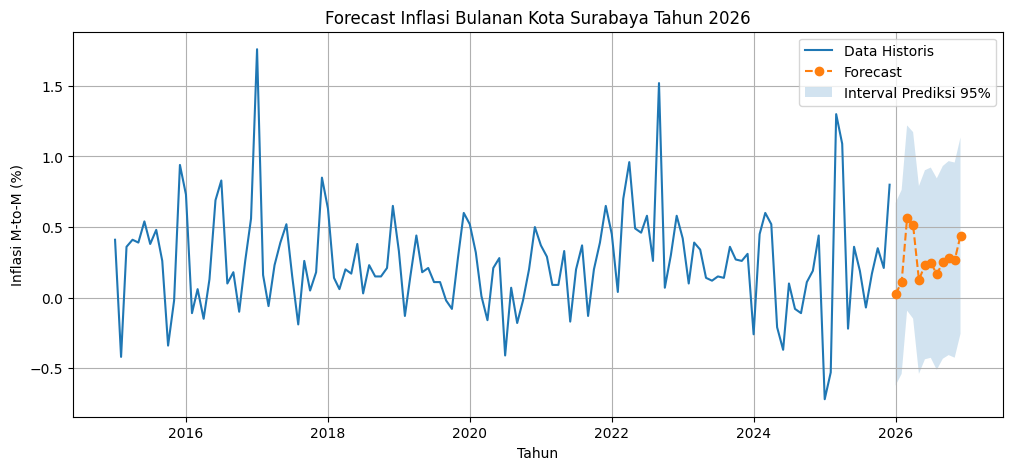

In [16]:
hasil_surabaya = run_sarima_pipeline(df_surabaya, "Kota Surabaya")

In [17]:
hasil_surabaya["results"].to_csv("top_model_sarima_surabaya.csv", index=False)
hasil_surabaya["eval_df"].to_csv("evaluasi_outsample_2025_surabaya.csv")
hasil_surabaya["forecast"].to_csv("forecast_inflasi_2026_surabaya.csv")

In [18]:
df_jatim = (
    df_jatim.groupby("Tanggal")["Inflasi"].mean().reset_index().rename(columns={
        "Tanggal": "tanggal",
        "Inflasi": "inflasi"
    }).set_index("tanggal").sort_index().asfreq("MS")
)

df_jatim = df_jatim.loc["2015-01-01":"2025-12-01"]
df_jatim.head()

,inflasi
tanggal,
2015-01-01,-0.05250
2015-02-01,-0.60875
2015-03-01,0.23125
2015-04-01,0.31750
2015-05-01,0.40250


ANALISIS SARIMA: Rata-rata Kota di Jawa Timur
Jumlah train: 120
Jumlah test: 12
Periode train: 2015-01-01 00:00:00 - 2024-12-01 00:00:00
Periode test: 2025-01-01 00:00:00 - 2025-12-01 00:00:00


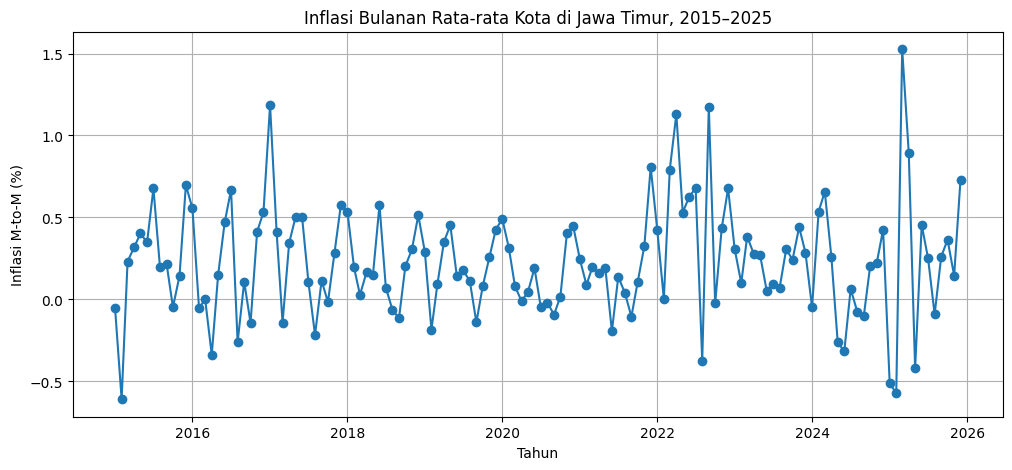

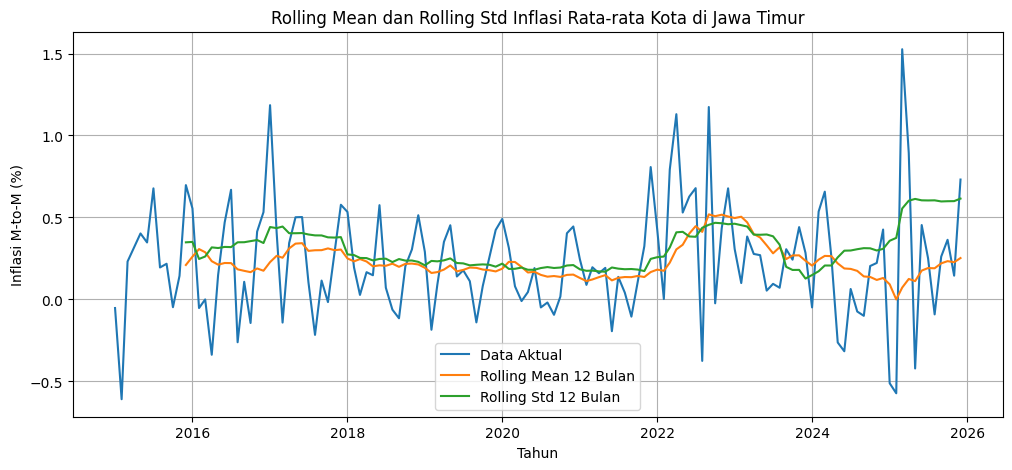

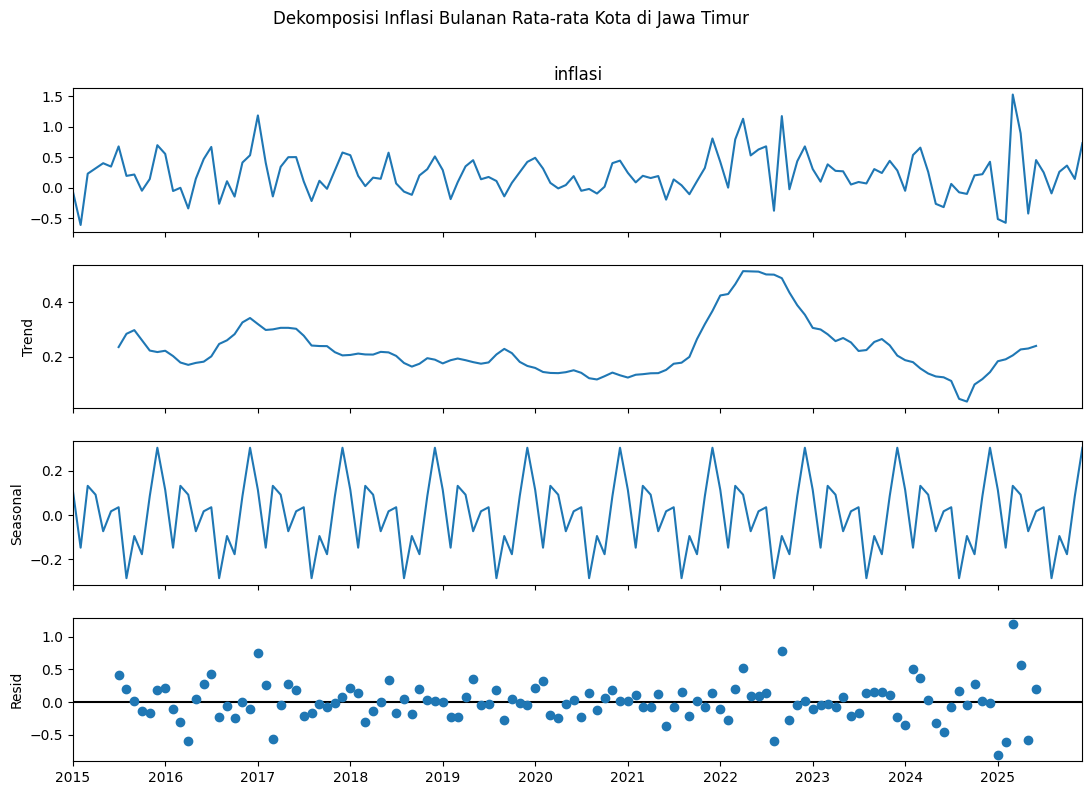

ADF Test - Rata-rata Kota di Jawa Timur - Data Train
ADF Statistic: -8.500255252188524
p-value: 1.2438658564066826e-13
Critical Values:
1%: -3.4865346059036564
5%: -2.8861509858476264
10%: -2.579896092790057
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Rata-rata Kota di Jawa Timur - Differencing Regular d=1
ADF Statistic: -6.471479217651011
p-value: 1.3637256722162853e-08
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Rata-rata Kota di Jawa Timur - Differencing Musiman D=1
ADF Statistic: -3.6159323619914296
p-value: 0.005463639471734951
Critical Values:
1%: -3.5003788874873405
5%: -2.8921519665075235
10%: -2.5830997960069446
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Rata-rata Kota di Jawa Timur - Differencing Regular d=1 dan Musiman D=1
ADF Statistic: 

<Figure size 1000x400 with 0 Axes>

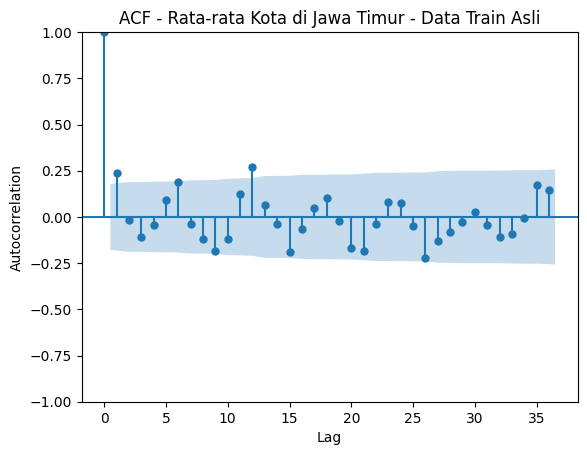

<Figure size 1000x400 with 0 Axes>

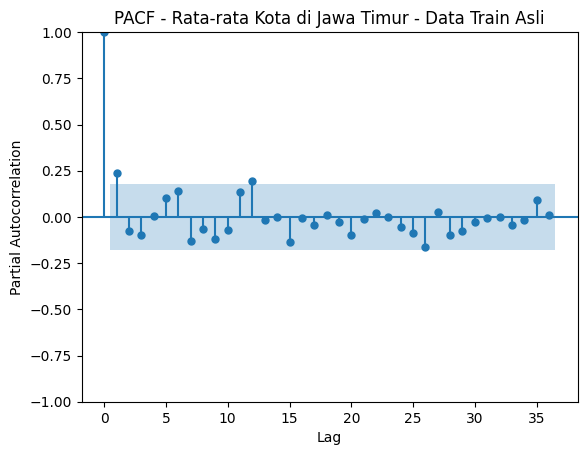

<Figure size 1000x400 with 0 Axes>

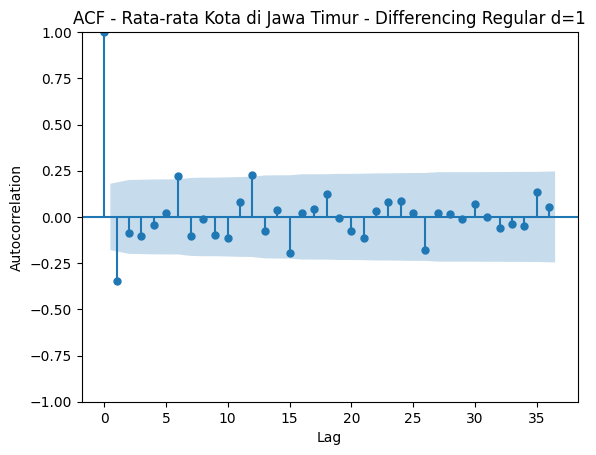

<Figure size 1000x400 with 0 Axes>

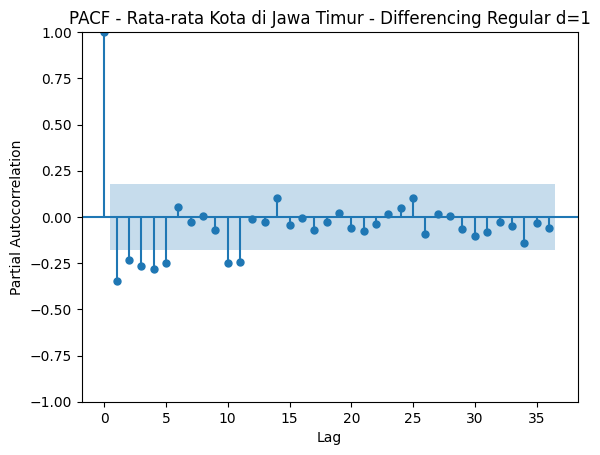

<Figure size 1000x400 with 0 Axes>

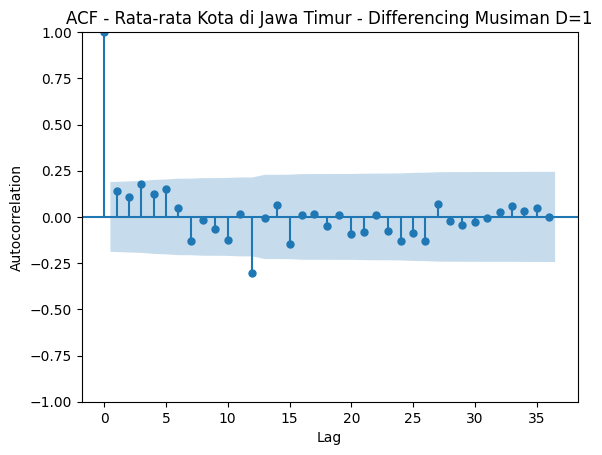

<Figure size 1000x400 with 0 Axes>

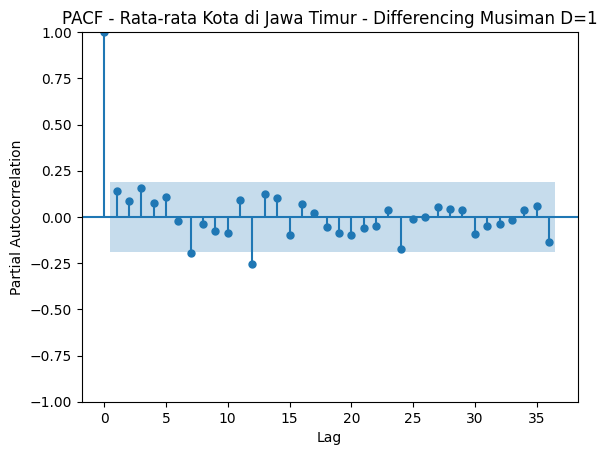

<Figure size 1000x400 with 0 Axes>

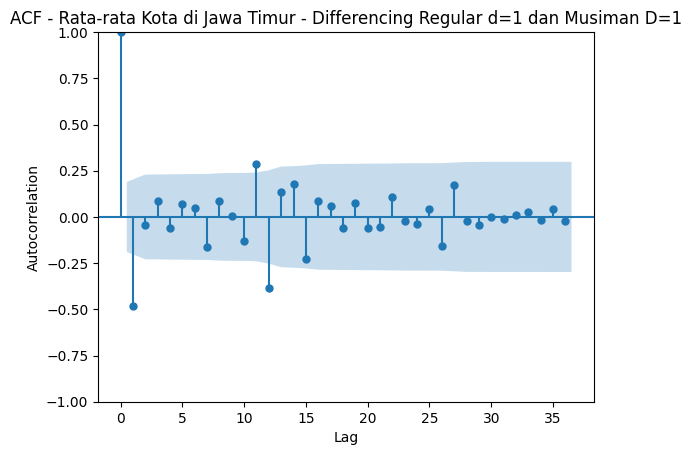

<Figure size 1000x400 with 0 Axes>

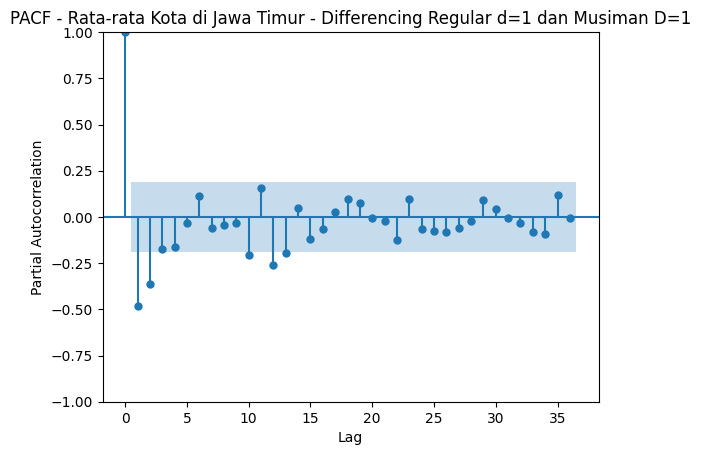

C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10 model terbaik berdasarkan AIC:


,order,seasonal_order,aic,bic,rmse,mae,ljungbox_pvalue,shapiro_pvalue
0,"(1, 1, 2)","(1, 0, 1, 12)",39.849753,55.716098,0.571522,0.455754,0.645708,0.029193
1,"(0, 1, 2)","(1, 0, 1, 12)",40.096062,53.318017,0.572875,0.456579,0.864174,0.011673
2,"(0, 1, 1)","(1, 0, 1, 12)",41.047217,51.663058,0.570598,0.455594,0.878149,0.010483
3,"(2, 1, 2)","(1, 0, 1, 12)",41.721753,60.232489,0.569449,0.454626,0.597243,0.028567
4,"(1, 1, 1)","(1, 0, 1, 12)",42.055769,55.325571,0.571832,0.455279,0.913525,0.003054
5,"(0, 0, 1)","(0, 1, 1, 12)",42.103978,49.733862,0.535081,0.417507,0.299036,0.003047
6,"(1, 0, 1)","(0, 1, 1, 12)",42.296478,52.469657,0.518718,0.410355,0.601421,0.017217
7,"(2, 1, 1)","(1, 0, 1, 12)",42.515666,58.439428,0.566447,0.452231,0.783144,0.013925
8,"(2, 0, 2)","(0, 1, 1, 12)",43.131395,58.326992,0.519285,0.410774,0.334584,0.016369
9,"(0, 0, 2)","(0, 1, 1, 12)",43.730207,53.860605,0.527715,0.413640,0.415418,0.005836


Jumlah model yang lolos diagnostic checking: 23
Model SARIMA terbaik:


order                  (2, 1, 2)
seasonal_order     (1, 1, 1, 12)
aic                    53.013745
bic                    70.666265
rmse                    0.470379
mae                     0.371399
ljungbox_pvalue         0.295008
shapiro_pvalue          0.309776
Name: 43, dtype: object

                                      SARIMAX Results                                       
Dep. Variable:                              inflasi   No. Observations:                  120
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 -19.507
Date:                              Mon, 22 Jun 2026   AIC                             53.014
Time:                                      19:13:05   BIC                             70.666
Sample:                                  01-01-2015   HQIC                            60.138
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7948      0.102      7.759      0.000       0.594       0.996
ar.L2         -0.30

,actual,forecast,error,abs_error,squared_error
tanggal,,,,,
2025-01-01,-0.51125,0.010852,-0.522102,0.522102,0.272590
2025-02-01,-0.57250,0.100444,-0.672944,0.672944,0.452854
2025-03-01,1.52625,0.519661,1.006589,1.006589,1.013222
2025-04-01,0.89250,0.530759,0.361741,0.361741,0.130856
2025-05-01,-0.42125,0.317298,-0.738548,0.738548,0.545454
2025-06-01,0.45375,0.210310,0.243440,0.243440,0.059263
2025-07-01,0.25125,0.324221,-0.072971,0.072971,0.005325
2025-08-01,-0.09125,0.054882,-0.146132,0.146132,0.021355
2025-09-01,0.26125,0.380699,-0.119449,0.119449,0.014268


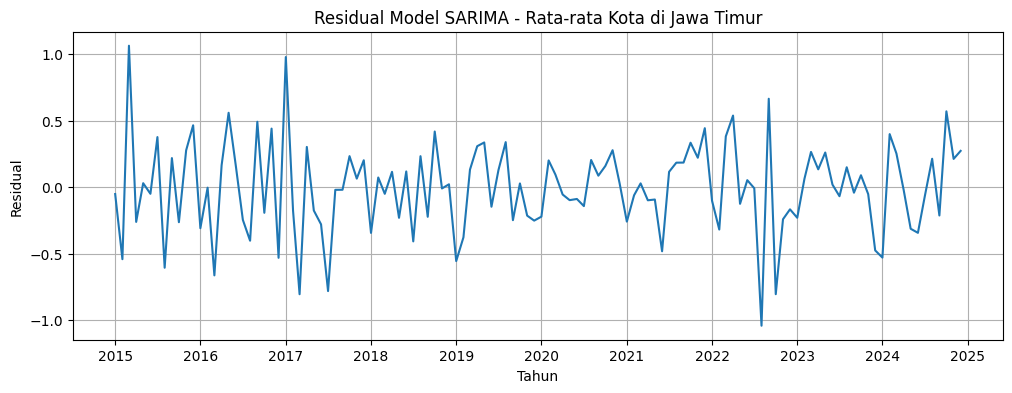

<Figure size 1000x400 with 0 Axes>

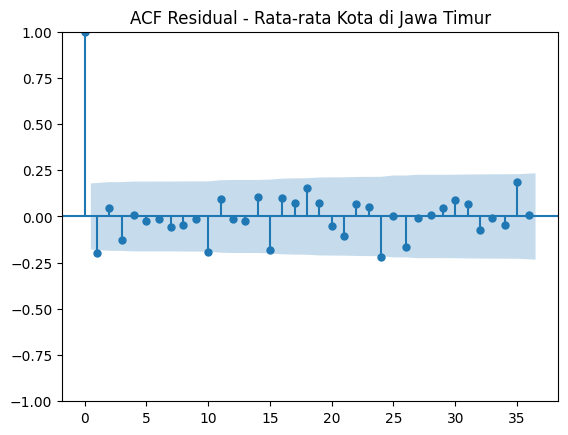

Ljung-Box Test:


,lb_stat,lb_pvalue
12,14.089848,0.295008
24,37.062309,0.043138


Shapiro-Wilk Test
Statistic: 0.987029922031234
p-value  : 0.30977646620028154
Forecast 12 bulan ke depan:


,forecast,lower_95,upper_95
2026-01-01,-0.096840,-0.717594,0.523913
2026-02-01,-0.180392,-0.802310,0.441527
2026-03-01,0.564661,-0.057739,1.187061
2026-04-01,0.263825,-0.388008,0.915657
2026-05-01,-0.336723,-1.064243,0.390797
2026-06-01,-0.120125,-0.934888,0.694639
2026-07-01,-0.020700,-0.911143,0.869742
2026-08-01,-0.274991,-1.228187,0.678204
2026-09-01,-0.022289,-1.030452,0.985874
2026-10-01,0.022933,-1.036475,1.082342


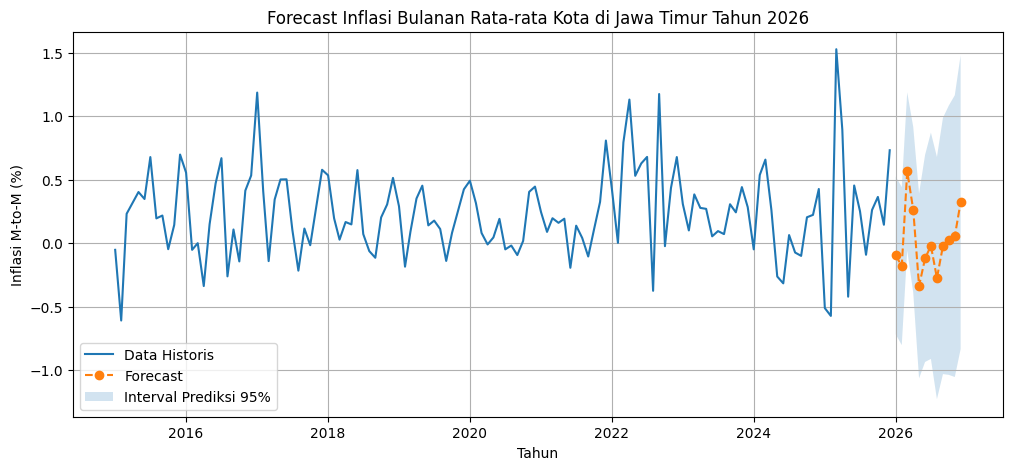

In [19]:
hasil_jatim = run_sarima_pipeline(df_jatim, "Rata-rata Kota di Jawa Timur")

In [20]:
df_summary = pd.DataFrame([
    hasil_indonesia["summary"],
    hasil_surabaya["summary"],
    hasil_jatim["summary"]
])

df_summary

,nama_data,order,seasonal_order,aic,bic,rmse,mae
0,Indonesia,"(2, 0, 2)","(1, 1, 0, 12)",41.009165,56.268934,0.590769,0.458016
1,Kota Surabaya,"(0, 1, 1)","(1, 0, 1, 12)",47.629114,58.244955,0.585442,0.452051
2,Rata-rata Kota di Jawa Timur,"(2, 1, 2)","(1, 1, 1, 12)",53.013745,70.666265,0.470379,0.371399
